# ☕ Bright Coffee Shop — Sales EDA & Dashboard

This notebook explores the Bright Coffee Shop sales dataset (Jan–Jun 2023, ~149K transactions
across 3 NYC store locations) and builds a set of dashboard-ready visualizations.

**What this notebook does:**
1. Loads and cleans the raw transaction data
2. Engineers useful date/time and revenue features
3. Runs descriptive / data-quality checks
4. Builds a set of `display()` charts (KPIs, trends, category & product breakdowns,
   peak-hour analysis, store comparison) that can each be pinned to a Databricks **Dashboard**
5. Produces a few static Matplotlib charts suitable for dropping into a slide deck
6. A short written summary of business insights at the end


In [0]:
# Create a notebook widget so the file path is easy to change from the notebook UI
# without editing code — useful once this becomes a scheduled/production notebook.
# NOTE: update this default to your actual catalog/schema/volume names, e.g.
#   /Volumes/main/default/bright_coffee/Bright_Coffee_Shop_Sales.csv
dbutils.widgets.text("data_path", "/Volumes/workspace/default/shoppingtrend/Bright_Coffee_Shop_Sales.csv", "CSV file path")
data_path = dbutils.widgets.get("data_path")
print(f"Reading data from: {data_path}")

Reading data from: /Volumes/workspace/default/shoppingtrend/Bright_Coffee_Shop_Sales.csv


## 1. Imports
We use PySpark for the heavy lifting (so this scales past a laptop-sized dataset and so
`display()` gives us native, pin-to-dashboard charts), plus a little Pandas/Matplotlib at the
end for static charts we can export straight into a slide deck.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import pandas as pd

# Cosmetic: keep matplotlib charts clean and readable when we get to the "for slides" section
plt.rcParams["figure.dpi"] = 110

## 2. Load raw data
The source CSV is `;`-delimited and uses a **comma as the decimal separator**
(e.g. `3,1` = 3.1), which is common for European-locale exports. We read every column as a
string first so nothing gets silently mangled, then cast types explicitly in the cleaning step.

In [0]:
raw_df = (
    spark.read
    .option("header", "true")
    .option("sep", ";")
    .option("encoding", "UTF-8")
    .csv(data_path)
)

print(f"Rows loaded: {raw_df.count():,}")
print(f"Columns: {raw_df.columns}")
raw_df.printSchema()

Rows loaded: 149,116
Columns: ['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']
root
 |-- transaction_id: string (nullable = true)
 |-- transaction_date: string (nullable = true)
 |-- transaction_time: string (nullable = true)
 |-- transaction_qty: string (nullable = true)
 |-- store_id: string (nullable = true)
 |-- store_location: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- unit_price: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- product_detail: string (nullable = true)



In [0]:
# Quick visual sanity check of the first few rows straight from the source file
display(raw_df.limit(10))

transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3,Coffee,Gourmet brewed coffee,Ethiopia Rg
2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,"3,1",Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,"4,5",Drinking Chocolate,Hot chocolate,Dark chocolate Lg
4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2,Coffee,Drip coffee,Our Old Time Diner Blend Sm
5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,"3,1",Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
6,2023-01-01,07:22:41,1,5,Lower Manhattan,77,3,Bakery,Scone,Oatmeal Scone
7,2023-01-01,07:25:49,1,5,Lower Manhattan,22,2,Coffee,Drip coffee,Our Old Time Diner Blend Sm
8,2023-01-01,07:33:34,2,5,Lower Manhattan,28,2,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm
9,2023-01-01,07:39:13,1,5,Lower Manhattan,39,"4,25",Coffee,Barista Espresso,Latte Rg
10,2023-01-01,07:39:34,2,5,Lower Manhattan,58,"3,5",Drinking Chocolate,Hot chocolate,Dark chocolate Rg


## 3. Data quality checks
confirm there are no unexpected nulls or duplicate transactions.

In [0]:
# Count nulls/blank strings per column — a null-heavy column would need a decision
# (drop, impute, or flag) before we build anything on top of it.
null_counts = raw_df.select([
    F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), c)).alias(c)
    for c in raw_df.columns
])
display(null_counts)

transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,0,0,0,0,0,0,0,0,0,0


In [0]:
# Duplicate transaction_id would mean double-counted sales — check for that specifically,
# then check for fully-duplicate rows as a second sanity check.
dup_ids = (
    raw_df.groupBy("transaction_id").count().filter(F.col("count") > 1).count()
)
dup_rows = raw_df.count() - raw_df.dropDuplicates().count()
print(f"Duplicate transaction_id values: {dup_ids}")
print(f"Fully duplicate rows: {dup_rows}")

Duplicate transaction_id values: 0
Fully duplicate rows: 0


Data is clean: no nulls, no duplicate transactions.

## 4. Clean & engineer features
- Cast numeric columns to proper types (fixing the comma decimal separator on `unit_price`)
- Parse `transaction_date` / `transaction_time` into real date/time types
- Add a `revenue` column (`transaction_qty * unit_price`) — the dataset has no pre-computed
  sales total, so every downstream revenue chart depends on this
- Add calendar features (month, day-of-week, hour, weekend flag) to support trend & peak-time analysis

In [0]:
df = (
    raw_df
    # unit_price arrives as e.g. "3,1" — swap the decimal comma for a dot before casting to double
    .withColumn("unit_price", F.regexp_replace(F.col("unit_price"), ",", ".").cast(DoubleType()))
    .withColumn("transaction_qty", F.col("transaction_qty").cast("int"))
    .withColumn("store_id", F.col("store_id").cast("int"))
    .withColumn("product_id", F.col("product_id").cast("int"))
    .withColumn("transaction_date", F.to_date("transaction_date", "yyyy-MM-dd"))
    .withColumn("transaction_time", F.to_timestamp("transaction_time", "HH:mm:ss"))
    # Revenue per line item — the core metric nearly every chart below is built from
    .withColumn("revenue", F.round(F.col("transaction_qty") * F.col("unit_price"), 2))
    # Calendar features for trend / seasonality analysis
    .withColumn("month", F.date_format("transaction_date", "yyyy-MM"))
    .withColumn("day_of_week", F.date_format("transaction_date", "E"))       # Mon, Tue, ...
    .withColumn("hour_of_day", F.hour("transaction_time"))
    .withColumn("is_weekend", F.dayofweek("transaction_date").isin([1, 7]))  # Sun=1, Sat=7
)

# NOTE: not calling .cache() here — explicit caching/persist isn't supported on
# serverless compute (NOT_SUPPORTED_WITH_SERVERLESS). Serverless automatically handles
# reuse/optimization of repeated scans under the hood, so this is safe to skip; on a
# classic (non-serverless) cluster you could add df.cache() back in for a speed-up.
print(f"Cleaned rows: {df.count():,}")
display(df.limit(10))

Cleaned rows: 149,116


transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,month,day_of_week,hour_of_day,is_weekend
1,2023-01-01,1970-01-01T07:06:11.000Z,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2023-01,Sun,7,true
2,2023-01-01,1970-01-01T07:08:56.000Z,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01,Sun,7,true
3,2023-01-01,1970-01-01T07:14:04.000Z,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2023-01,Sun,7,true
4,2023-01-01,1970-01-01T07:20:24.000Z,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023-01,Sun,7,true
5,2023-01-01,1970-01-01T07:22:41.000Z,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01,Sun,7,true
6,2023-01-01,1970-01-01T07:22:41.000Z,1,5,Lower Manhattan,77,3.0,Bakery,Scone,Oatmeal Scone,3.0,2023-01,Sun,7,true
7,2023-01-01,1970-01-01T07:25:49.000Z,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023-01,Sun,7,true
8,2023-01-01,1970-01-01T07:33:34.000Z,2,5,Lower Manhattan,28,2.0,Coffee,Gourmet brewed coffee,Columbian Medium Roast Sm,4.0,2023-01,Sun,7,true
9,2023-01-01,1970-01-01T07:39:13.000Z,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg,4.25,2023-01,Sun,7,true
10,2023-01-01,1970-01-01T07:39:34.000Z,2,5,Lower Manhattan,58,3.5,Drinking Chocolate,Hot chocolate,Dark chocolate Rg,7.0,2023-01,Sun,7,true


In [0]:
# Register as a SQL temp view — lets us mix %sql cells or Databricks SQL dashboard
# queries against the same cleaned data without re-running the Python cleaning logic.
df.createOrReplaceTempView("bright_coffee_sales")

## 5. Descriptive statistics
A standard EDA pass over the numeric columns — sanity-checks ranges (e.g. no negative quantities
or prices) and gives a feel for the spread of order sizes and prices before we dashboard on top.

In [0]:
display(df.select("transaction_qty", "unit_price", "revenue").describe())

summary,transaction_qty,unit_price,revenue
count,149116,149116,149116
mean,1.438276241315486,3.382219413074346,4.6863671906435025
stddev,0.542508764737219,2.6587226166627156,4.227099064468094
min,1,0.8,0.8
max,8,45.0,360.0


## 6. 📊 Dashboard section


### 6.1 Headline KPIs
A single summary row — total revenue, total transactions, units sold, and average order value.
Pin this as a table/counter tile at the top of the dashboard.

In [0]:
kpis = df.agg(
    F.round(F.sum("revenue"), 2).alias("total_revenue"),
    F.count("transaction_id").alias("total_transactions"),
    F.sum("transaction_qty").alias("total_units_sold"),
    F.round(F.avg("revenue"), 2).alias("avg_line_item_value"),
    F.countDistinct("store_location").alias("store_count"),
)
display(kpis)

total_revenue,total_transactions,total_units_sold,avg_line_item_value,store_count
698812.33,149116,214470,4.69,3


### 6.2 Daily sales trend
Total revenue per calendar day across the full Jan–Jun 2023 window — the main "is the business
growing" chart. Recommended chart type when pinning: **Line**.

In [0]:
daily_sales = (
    df.groupBy("transaction_date")
    .agg(F.round(F.sum("revenue"), 2).alias("daily_revenue"))
    .orderBy("transaction_date")
)
display(daily_sales)

transaction_date,daily_revenue
2023-01-01,2508.2
2023-01-02,2403.35
2023-01-03,2565.0
2023-01-04,2220.1
2023-01-05,2418.85
2023-01-06,2273.85
2023-01-07,2619.65
2023-01-08,2638.53
2023-01-09,2676.61
2023-01-10,2685.65


### 6.3 Monthly sales trend
Same idea rolled up to month-level, which is easier to read at a glance and better for
month-over-month growth commentary. Recommended chart type: **Bar** or **Line**.

In [0]:
monthly_sales = (
    df.groupBy("month")
    .agg(
        F.round(F.sum("revenue"), 2).alias("monthly_revenue"),
        F.sum("transaction_qty").alias("units_sold"),
        F.countDistinct("transaction_date").alias("days_in_period"),
    )
    .orderBy("month")
)
display(monthly_sales)

month,monthly_revenue,units_sold,days_in_period
2023-01,81677.74,24870,31
2023-02,76145.19,23550,28
2023-03,98834.68,30406,31
2023-04,118941.08,36469,30
2023-05,156727.76,48233,31
2023-06,166485.88,50942,30


### 6.4 Revenue by product category
Which categories (Coffee, Tea, Bakery, etc.) drive the most revenue. Recommended chart type:
**Bar**, sorted descending — or **Pie** if you want a share-of-revenue view.

In [0]:
revenue_by_category = (
    df.groupBy("product_category")
    .agg(
        F.round(F.sum("revenue"), 2).alias("total_revenue"),
        F.sum("transaction_qty").alias("units_sold"),
    )
    .orderBy(F.desc("total_revenue"))
)
display(revenue_by_category)

product_category,total_revenue,units_sold
Coffee,269952.45,89250
Tea,196405.95,69737
Bakery,82315.64,23214
Drinking Chocolate,72416.0,17457
Coffee beans,40085.25,1828
Branded,13607.0,776
Loose Tea,11213.6,1210
Flavours,8408.8,10511
Packaged Chocolate,4407.64,487


### 6.5 Top 10 products by revenue
Drills below category into the specific `product_type` driving the most sales — useful for
"what should we stock more of" conversations. Recommended chart type: **Bar** (horizontal).

In [0]:
top_products = (
    df.groupBy("product_type")
    .agg(
        F.round(F.sum("revenue"), 2).alias("total_revenue"),
        F.sum("transaction_qty").alias("units_sold"),
    )
    .orderBy(F.desc("total_revenue"))
    .limit(10)
)
display(top_products)

product_type,total_revenue,units_sold
Barista Espresso,91406.2,24943
Brewed Chai tea,77081.95,26250
Hot chocolate,72416.0,17457
Gourmet brewed coffee,70034.6,25973
Brewed Black tea,47932.0,17462
Brewed herbal tea,47539.5,17328
Premium brewed coffee,38781.15,12431
Organic brewed coffee,37746.5,13012
Scone,36866.12,10465
Drip coffee,31984.0,12891


### 6.6 Peak sales hours
Revenue and transaction count by hour of day — identifies staffing/inventory peaks (coffee
shops classically spike in the morning). Recommended chart type: **Bar** or **Line**.

In [0]:
sales_by_hour = (
    df.groupBy("hour_of_day")
    .agg(
        F.round(F.sum("revenue"), 2).alias("total_revenue"),
        F.count("transaction_id").alias("transaction_count"),
    )
    .orderBy("hour_of_day")
)
display(sales_by_hour)

hour_of_day,total_revenue,transaction_count
6,21900.27,4594
7,63526.47,13428
8,82699.87,17654
9,85169.53,17764
10,88673.39,18545
11,46319.14,9766
12,40192.79,8708
13,40367.45,8714
14,41304.74,8933
15,41733.1,8979


### 6.7 Sales by day of week
Shows whether weekends outperform weekdays (or vice versa) — useful for weekend
staffing/promo decisions. Recommended chart type: **Bar**.

In [0]:
# Order the categorical day names Mon->Sun instead of the default alphabetical sort
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

sales_by_dow = (
    df.groupBy("day_of_week")
    .agg(
        F.round(F.sum("revenue"), 2).alias("total_revenue"),
        F.count("transaction_id").alias("transaction_count"),
    )
    .withColumn("day_order", F.array_position(F.array(*[F.lit(d) for d in day_order]), F.col("day_of_week")))
    .orderBy("day_order")
    .drop("day_order")
)
display(sales_by_dow)

day_of_week,total_revenue,transaction_count
Mon,101677.28,21643
Tue,99455.94,21202
Wed,100313.54,21310
Thu,100767.78,21654
Fri,101373.0,21701
Sat,96894.48,20510
Sun,98330.31,21096


### 6.8 Revenue by store location
Compares the three store locations head-to-head. Recommended chart type: **Bar** or **Pie**.

In [0]:
revenue_by_store = (
    df.groupBy("store_location")
    .agg(
        F.round(F.sum("revenue"), 2).alias("total_revenue"),
        F.count("transaction_id").alias("transaction_count"),
        F.round(F.avg("revenue"), 2).alias("avg_line_item_value"),
    )
    .orderBy(F.desc("total_revenue"))
)
display(revenue_by_store)

store_location,total_revenue,transaction_count,avg_line_item_value
Hell's Kitchen,236511.17,50735,4.66
Astoria,232243.91,50599,4.59
Lower Manhattan,230057.25,47782,4.81


### 6.9 Order value distribution
How big is a typical line-item sale? A right-skewed histogram here would suggest most sales
are small/single-item with a long tail of bigger orders. Recommended chart type: **Histogram**.

In [0]:
# Cap the display at the 99th percentile so a handful of large outlier orders don't
# squash the histogram's bin widths and hide the shape of the bulk of the data.
p99 = df.approxQuantile("revenue", [0.99], 0.01)[0]
display(df.filter(F.col("revenue") <= p99).select("revenue"))

revenue
6.0
6.2
9.0
2.0
6.2
3.0
2.0
4.0
4.25
7.0


In [0]:
# Pull the small, already-aggregated tables to the driver as Pandas — safe to do here because these are group-by summaries (a handful of rows), not the raw 149K-row dataset.
monthly_pd = monthly_sales.toPandas()
category_pd = revenue_by_category.toPandas()
top_products_pd = top_products.toPandas()
hour_pd = sales_by_hour.toPandas()

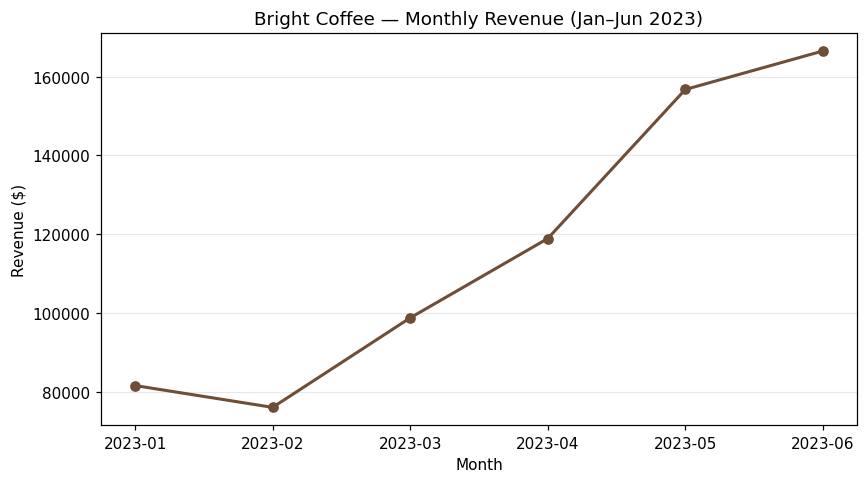

In [0]:
# Chart 1: Monthly revenue trend — the "how's the business doing over time" slide
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(monthly_pd["month"], monthly_pd["monthly_revenue"], marker="o", linewidth=2, color="#6F4E37")
ax.set_title("Bright Coffee — Monthly Revenue (Jan–Jun 2023)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("monthly_revenue_trend.png")
plt.show()

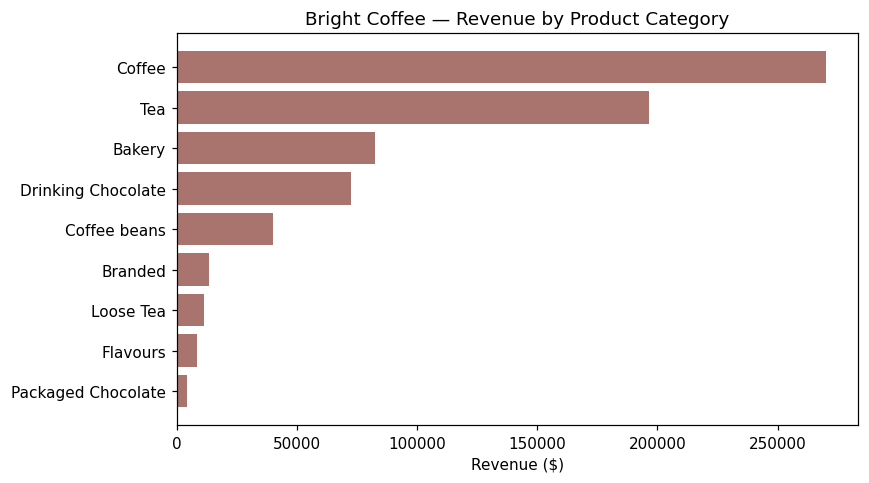

In [0]:
# Chart 2: Revenue by category — the "what are we selling" slide
category_sorted = category_pd.sort_values("total_revenue", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(category_sorted["product_category"], category_sorted["total_revenue"], color="#A9746E")
ax.set_title("Bright Coffee — Revenue by Product Category")
ax.set_xlabel("Revenue ($)")
plt.tight_layout()
plt.savefig("revenue_by_category.png")
plt.show()

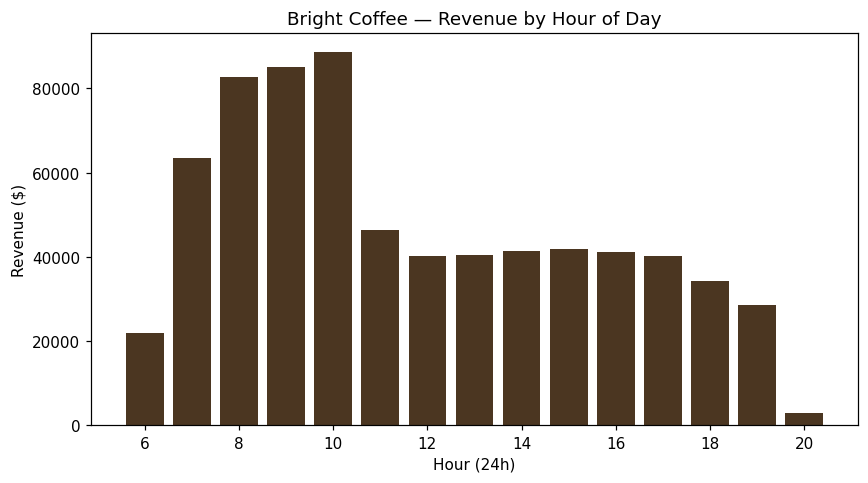

In [0]:
# Chart 3: Peak hours — the "when are we busiest" slide
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(hour_pd["hour_of_day"], hour_pd["total_revenue"], color="#4B3621")
ax.set_title("Bright Coffee — Revenue by Hour of Day")
ax.set_xlabel("Hour (24h)")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("revenue_by_hour.png")
plt.show()


## BRIGHT COFFEE — KEY INSIGHTS (Jan–Jun 2023)

- • Total revenue across all stores: $698,812.33
- • Top-selling category: Coffee ($269,952.45)
- • Best-selling product type: Barista Espresso ($91,406.20)
- • Peak sales hour: 10:00 ($88,673.39 in revenue)
- • Top-performing store: Hell's Kitchen ($236,511.17)
- • Strongest month: 2023-06 ($166,485.88)

##RECOMMENDATIONS
- • Double-check staffing levels around the 10:00 peak hour to avoid long queues.
- • Consider promoting or bundling top categories/products in weaker categories to lift their share.
- • Investigate what the top-performing store is doing differently (foot traffic, staffing, local
-   promotions) and evaluate rolling out those practices to the other locations.
- • Layer on the previous years' data (if available) to distinguish real seasonality from short-term
 noise before making inventory or staffing changes.
